# Retail Store Inventory Forecasting — Environment Demo
This notebook confirms the data-science environment works end-to-end: load the dataset, inspect it, and train a demand-forecasting model.

In [1]:
import pandas as pd, numpy as np, sklearn, statsmodels, matplotlib, seaborn
print('pandas', pd.__version__, '| numpy', np.__version__, '| scikit-learn', sklearn.__version__)
df = pd.read_csv('../retail_store_inventory.csv', parse_dates=['Date'])
print('rows:', len(df))
df.head()

pandas 3.0.6 | numpy 2.5.3 | scikit-learn 1.9.1
rows: 73100


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


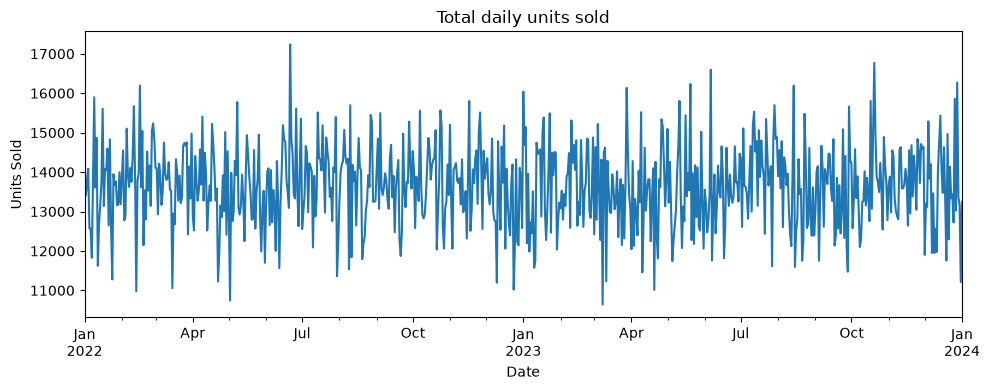

In [2]:
import matplotlib.pyplot as plt
daily = df.groupby('Date')['Units Sold'].sum()
ax = daily.plot(figsize=(10,4), title='Total daily units sold')
ax.set_ylabel('Units Sold')
plt.tight_layout(); plt.show()

In [3]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error

feat = pd.get_dummies(df, columns=['Category','Region','Weather Condition','Seasonality'], drop_first=True)
feat['month'] = feat['Date'].dt.month
cutoff = feat['Date'].quantile(0.8)
cols = [c for c in feat.columns if c not in {'Units Sold','Date','Store ID','Product ID','Demand Forecast'}]
tr, te = feat[feat.Date<=cutoff], feat[feat.Date>cutoff]
m = HistGradientBoostingRegressor(max_iter=200, random_state=42).fit(tr[cols], tr['Units Sold'])
p = m.predict(te[cols])
print('R^2 =', round(r2_score(te['Units Sold'], p), 4), '| MAE =', round(mean_absolute_error(te['Units Sold'], p), 3))

R^2 = 0.3402 | MAE = 68.767
